In [ ]:
# wbgapi is the only library not pre-installed on Colab — one line fixes it
!pip install wbgapi -q

import wbgapi as wb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded ✓")


All libraries loaded ✓


In [ ]:
# These are the 12 biggest European economies
europe = ['DEU','FRA','ITA','ESP','POL','NLD',
          'BEL','AUT','SWE','CZE','HUN','PRT']

# Pull trade openness data (Trade as % of GDP) from World Bank API
df = wb.data.DataFrame(
    'NE.TRD.GNFS.ZS',   # indicator code
    economy=europe,
    time=range(1990, 2023)
)

df.head()

,YR1990,YR1991,YR1992,YR1993,YR1994,YR1995,YR1996,YR1997,YR1998,YR1999,...,YR2013,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022
economy,,,,,,,,,,,,,,,,,,,,,
AUT,71.769482,70.323857,67.896109,63.513827,66.246574,68.525006,70.469316,75.244476,77.349522,78.562933,...,104.985374,104.496740,103.117582,101.573495,105.556067,108.377970,108.207285,99.948214,111.032932,123.579579
BEL,121.467851,118.590138,115.069288,109.012737,113.232300,116.378568,119.212776,125.688940,124.709123,125.169991,...,157.573623,158.571611,155.068682,159.057697,166.904078,168.277693,165.465479,156.950121,177.381892,191.179031
CZE,63.051279,70.771228,77.961131,78.197738,74.803018,82.900999,80.599558,84.153231,83.938652,85.457124,...,145.502231,156.415123,154.018401,148.547005,147.750835,145.141718,138.154610,128.780430,137.378116,144.011494
DEU,45.688955,47.635413,44.684044,39.749394,41.095744,42.606149,43.903586,48.380321,50.155466,51.519227,...,77.586029,76.848352,77.756582,76.005990,77.454839,79.125226,79.073243,72.933533,79.919535,88.785754
ESP,35.652905,35.520659,36.020774,36.995162,41.695880,44.830628,46.297751,51.227140,52.730313,54.696913,...,61.668773,63.399262,63.582041,63.188678,66.167446,67.009410,66.366225,59.446128,66.524589,78.465734


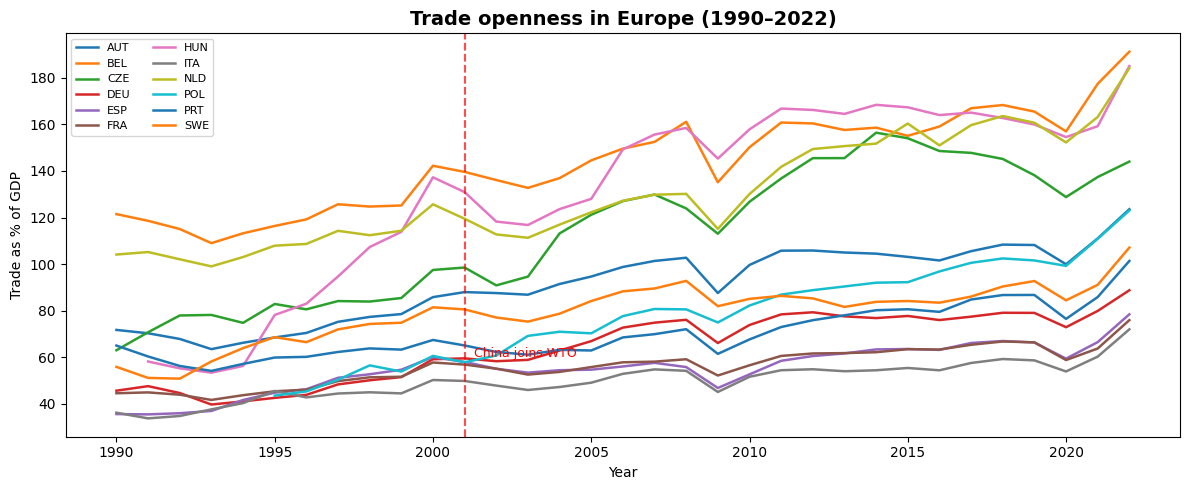

In [ ]:
# Transpose so years are rows, countries are columns
df = df.T

# Now clean the index
df.index = df.index.str.replace('YR', '').astype(int)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
df.plot(ax=ax, linewidth=1.8)

ax.set_title('Trade openness in Europe (1990–2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Trade as % of GDP')
ax.legend(loc='upper left', fontsize=8, ncol=2)

ax.axvline(x=2001, color='red', linestyle='--', alpha=0.7)
ax.text(2001.3, 60, 'China joins WTO', color='red', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Manufacturing value added (% of GDP)
# This tells us who competed directly with Chinese factories
mfg = wb.data.DataFrame(
    'NV.IND.MANF.ZS',
    economy=europe,
    time=range(1990, 2023)
)

mfg = mfg.T
mfg.index = mfg.index.str.replace('YR', '').astype(int)

# Who was most exposed when China entered in 2001?
exposure_2001 = mfg.loc[2001].sort_values(ascending=False)
print("Manufacturing as % of GDP in 2001 (higher = more exposed to China):\n")
print(exposure_2001.round(1))

Manufacturing as % of GDP in 2001 (higher = more exposed to China):

economy
CZE    23.5
DEU    20.1
HUN    19.2
SWE    19.0
AUT    18.9
ITA    17.2
BEL    17.0
ESP    15.8
PRT    14.7
POL    14.4
FRA    13.9
NLD    12.5
Name: 2001, dtype: float64


In [ ]:
# We'll approximate Chinese import growth using World Bank import data
# China's exports to the world = Europe's competition

# Indicator: MS.MIL.XPND.GD.ZS -- wait, wrong one
# We want: TM.VAL.MRCH.CD.WT = Merchandise imports (current USD)
# But more precise: let's pull China's export growth directly

china_exports = wb.data.DataFrame(
    'NE.EXP.GNFS.CD',   # Exports of goods and services (current USD)
    economy=['CHN'],
    time=range(1995, 2023)
)

china_exports = china_exports.T
china_exports.index = china_exports.index.str.replace('YR','').astype(int)
china_exports.columns = ['China_exports_USD']

# Convert to billions for readability
china_exports['China_exports_bn'] = china_exports['China_exports_USD'] / 1e9

print(china_exports[['China_exports_bn']].round(1))

      China_exports_bn
1995             131.9
1996             154.8
1997             187.4
1998             188.8
1999             198.7
2000             253.1
2001             272.1
2002             333.0
2003             448.0
2004             607.4
2005             773.3
2006             991.7
2007            1258.1
2008            1497.9
2009            1262.7
2010            1654.8
2011            2006.3
2012            2175.1
2013            2354.3
2014            2462.8
2015            2362.1
2016            2200.0
2017            2424.2
2018            2655.6
2019            2628.9
2020            2729.9
2021            3554.1
2022            3717.9


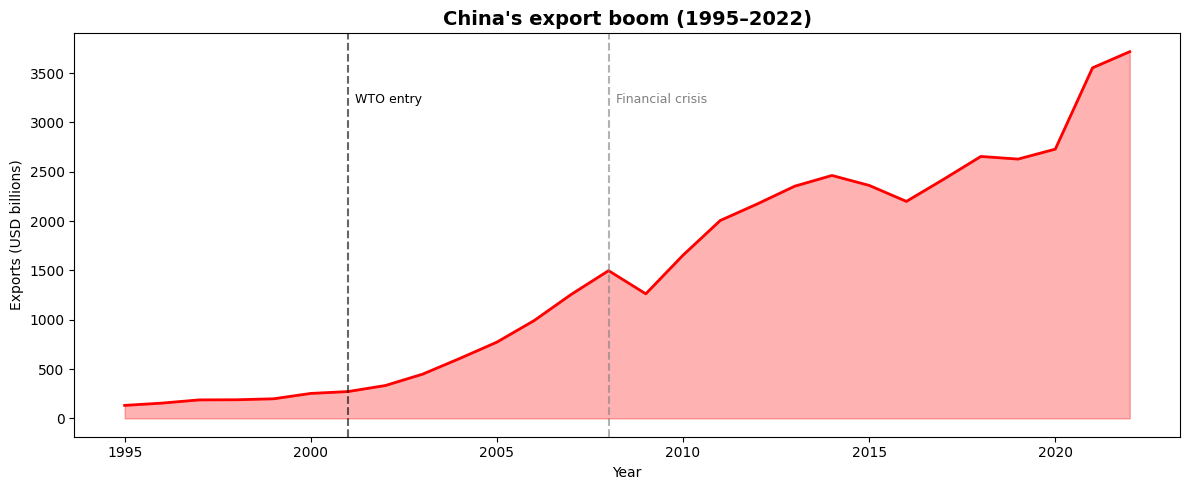

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(china_exports.index,
                china_exports['China_exports_bn'],
                alpha=0.3, color='red')
ax.plot(china_exports.index,
        china_exports['China_exports_bn'],
        color='red', linewidth=2)

# Mark the key moments
ax.axvline(x=2001, color='black', linestyle='--', alpha=0.6)
ax.text(2001.2, 3200, 'WTO entry', fontsize=9)

ax.axvline(x=2008, color='grey', linestyle='--', alpha=0.6)
ax.text(2008.2, 3200, 'Financial crisis', fontsize=9, color='grey')

ax.set_title("China's export boom (1995–2022)", fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Exports (USD billions)')

plt.tight_layout()
plt.show()

In [9]:
# Pull unemployment data — this is what the shock supposedly caused
unemp = wb.data.DataFrame(
    'SL.UEM.TOTL.ZS',
    economy=europe,
    time=range(1995, 2023)
)
unemp = unemp.T
unemp.index = unemp.index.str.replace('YR','').astype(int)

# Now build the exposure index
# For each country: manufacturing share in 2001 × growth in China exports post-2001

china_growth = (china_exports.loc[2015, 'China_exports_bn'] -
                china_exports.loc[2001, 'China_exports_bn'])

print(f"China export growth 2001-2015: ${china_growth:.0f} billion")

# Exposure index per country = manufacturing share (2001) × china export growth
exposure = mfg.loc[2001] * china_growth / 1000  # scale it down

exposure_df = pd.DataFrame({
    'manufacturing_share_2001': mfg.loc[2001].round(1),
    'exposure_index': exposure.round(1),
    'unemployment_2015': unemp.loc[2015].round(1)
}).sort_values('exposure_index', ascending=False)

print("\nYour exposure index — the core result:\n")
print(exposure_df)

China export growth 2001-2015: $2090 billion

Your exposure index — the core result:

         manufacturing_share_2001  exposure_index  unemployment_2015
economy                                                             
CZE                          23.5            49.2                5.0
DEU                          20.1            42.0                4.6
HUN                          19.2            40.0                6.8
SWE                          19.0            39.6                7.4
AUT                          18.9            39.4                5.8
ITA                          17.2            35.9               11.9
BEL                          17.0            35.6                8.5
ESP                          15.8            33.1               22.1
PRT                          14.7            30.7               12.4
POL                          14.4            30.1                7.5
FRA                          13.9            29.1               10.4
NLD              

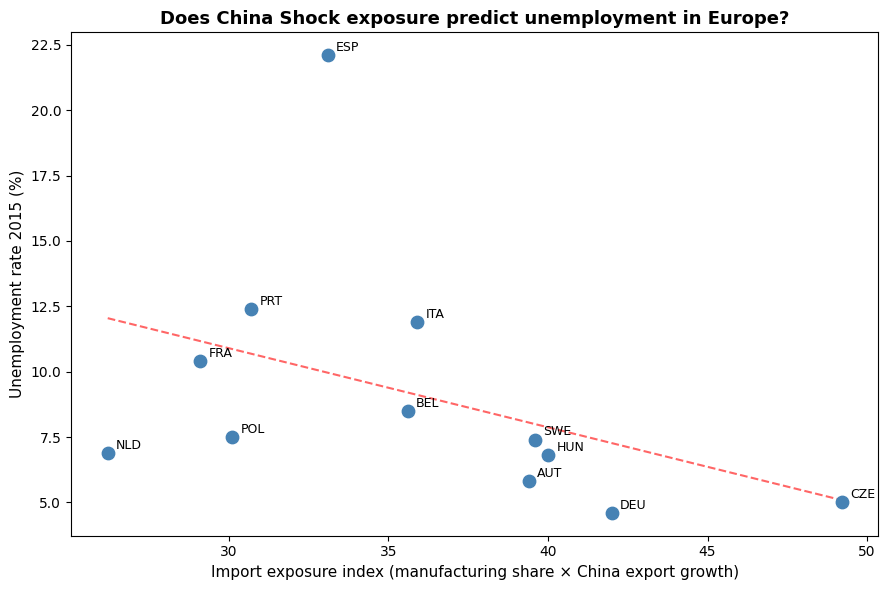

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

# Plot each country as a dot
for country in exposure_df.index:
    ax.scatter(exposure_df.loc[country, 'exposure_index'],
               exposure_df.loc[country, 'unemployment_2015'],
               s=80, color='steelblue', zorder=5)
    ax.annotate(country,
                (exposure_df.loc[country, 'exposure_index'],
                 exposure_df.loc[country, 'unemployment_2015']),
                textcoords="offset points", xytext=(6, 3), fontsize=9)

# Add a trend line
import numpy as np
x = exposure_df['exposure_index']
y = exposure_df['unemployment_2015']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(sorted(x), p(sorted(x)), "r--", alpha=0.6, linewidth=1.5)

ax.set_xlabel('Import exposure index (manufacturing share × China export growth)', fontsize=11)
ax.set_ylabel('Unemployment rate 2015 (%)', fontsize=11)
ax.set_title('Does China Shock exposure predict unemployment in Europe?',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
import statsmodels.api as sm

X = sm.add_constant(exposure_df['exposure_index'])
y = exposure_df['unemployment_2015']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      unemployment_2015   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     2.021
Date:                Tue, 02 Jun 2026   Prob (F-statistic):              0.186
Time:                        22:31:58   Log-Likelihood:                -34.221
No. Observations:                  12   AIC:                             72.44
Df Residuals:                      10   BIC:                             73.41
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             19.9667      7.752      2.

OLS estimation yields a negative coefficient of -0.30 on the import exposure index, suggesting that countries more exposed to Chinese import competition experienced lower unemployment in 2015, contrary to findings for the United States (Autor et al., 2013). The result is not statistically significant (p=0.186), consistent with the limited sample of 12 economies. The R² of 0.17 indicates that import exposure explains a modest share of cross-country unemployment variation, with institutional factors likely accounting for the remainder.


In [13]:
# Expand to more European countries for a fuller map
europe_full = ['DEU','FRA','ITA','ESP','POL','NLD','BEL','AUT',
               'SWE','CZE','HUN','PRT','GRC','ROU','SVK','FIN',
               'DNK','NOR','CHE','GBR','UKR','SVN','HRV','BGR']

# Pull manufacturing data for all of them
mfg_full = wb.data.DataFrame(
    'NV.IND.MANF.ZS',
    economy=europe_full,
    time=range(2000, 2003)
)
mfg_full = mfg_full.T
mfg_full.index = mfg_full.index.str.replace('YR','').astype(int)

# Build exposure index for all countries
exposure_full = pd.DataFrame({
    'manufacturing_share_2001': mfg_full.loc[2001],
    'exposure_index': mfg_full.loc[2001] * china_growth / 1000,
    'country_code': mfg_full.loc[2001].index
}).dropna()

# Draw the map
fig = px.choropleth(
    exposure_full,
    locations='country_code',
    color='exposure_index',
    hover_name='country_code',
    color_continuous_scale='RdYlGn_r',
    scope='europe',
    title='China Shock Import Exposure Index — Europe (2001–2015)'
)

fig.update_layout(
    coloraxis_colorbar_title='Exposure\nIndex',
    margin=dict(l=0, r=0, t=50, b=0),
    title_font_size=14
)

fig.show()